In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('./v3/train_history.csv')

df.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_cer,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,3.070491,1.664795,0.000010,0.226757,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,0.226757,50,0.52195,0.120490,45.1097,10.042,1.264,NaN,NaN,NaN,NaN,NaN
2,0.953462,1.691583,0.000010,0.453515,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,0.453515,100,0.33493,0.086068,45.1028,10.044,1.264,NaN,NaN,NaN,NaN,NaN
4,0.775154,3.300119,0.000009,0.680272,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_train = df[df['loss'].notna()].copy()
df_eval = df[df['eval_loss'].notna()].copy()

print("df_train head:")
print(df_train.head())
print("\ndf_eval head:")
print(df_eval.head())

df_train head:
       loss  grad_norm  learning_rate     epoch  step  eval_loss  eval_cer  \
0  3.070491   1.664795       0.000010  0.226757    50        NaN       NaN   
2  0.953462   1.691583       0.000010  0.453515   100        NaN       NaN   
4  0.775154   3.300119       0.000009  0.680272   150        NaN       NaN   
6  0.701032   1.750086       0.000009  0.907029   200        NaN       NaN   
8  0.626419   2.071666       0.000009  1.131519   250        NaN       NaN   

   eval_runtime  eval_samples_per_second  eval_steps_per_second  \
0           NaN                      NaN                    NaN   
2           NaN                      NaN                    NaN   
4           NaN                      NaN                    NaN   
6           NaN                      NaN                    NaN   
8           NaN                      NaN                    NaN   

   train_runtime  train_samples_per_second  train_steps_per_second  \
0            NaN                       NaN 

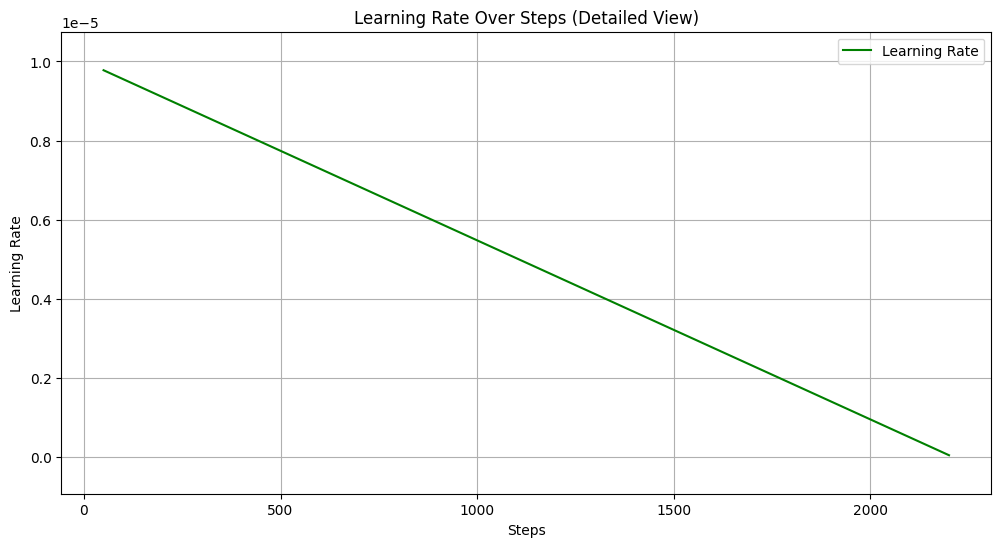

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_train['step'], df_train['learning_rate'], label='Learning Rate', color='green')
plt.title('Learning Rate Over Steps (Detailed View)')
plt.xlabel('Steps')
plt.ylabel('Learning Rate')

# Calculate dynamic y-axis limits to show more detail
lr_min = df_train['learning_rate'].min()
lr_max = df_train['learning_rate'].max()
padding = (lr_max - lr_min) * 0.1 # Add 10% padding
plt.ylim(lr_min - padding, lr_max + padding)

plt.legend()
plt.grid(True)
plt.show()

In [5]:
print("NaNs in df_train['grad_norm'] before dropping:", df_train['grad_norm'].isna().sum())
print("NaNs in df_eval['eval_cer'] before dropping:", df_eval['eval_cer'].isna().sum())

df_train.dropna(subset=['grad_norm'], inplace=True)
df_eval.dropna(subset=['eval_cer'], inplace=True)

print("NaNs in df_train['grad_norm'] after dropping:", df_train['grad_norm'].isna().sum())
print("NaNs in df_eval['eval_cer'] after dropping:", df_eval['eval_cer'].isna().sum())

print("df_train shape after cleaning:", df_train.shape)
print("df_eval shape after cleaning:", df_eval.shape)

NaNs in df_train['grad_norm'] before dropping: 0
NaNs in df_eval['eval_cer'] before dropping: 0
NaNs in df_train['grad_norm'] after dropping: 0
NaNs in df_eval['eval_cer'] after dropping: 0
df_train shape after cleaning: (44, 15)
df_eval shape after cleaning: (44, 15)


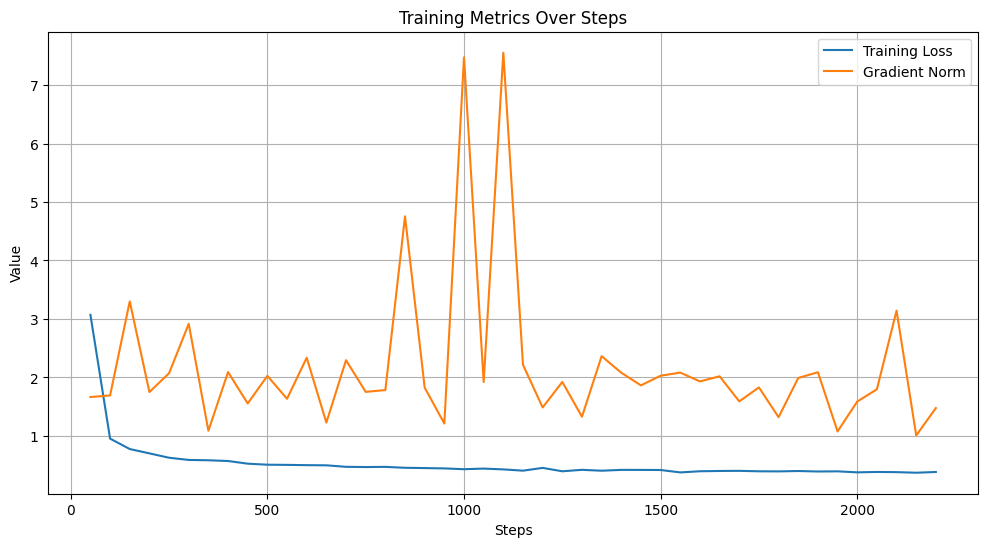

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_train['step'], df_train['loss'], label='Training Loss')
plt.plot(df_train['step'], df_train['grad_norm'], label='Gradient Norm')
plt.title('Training Metrics Over Steps')
plt.xlabel('Steps')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

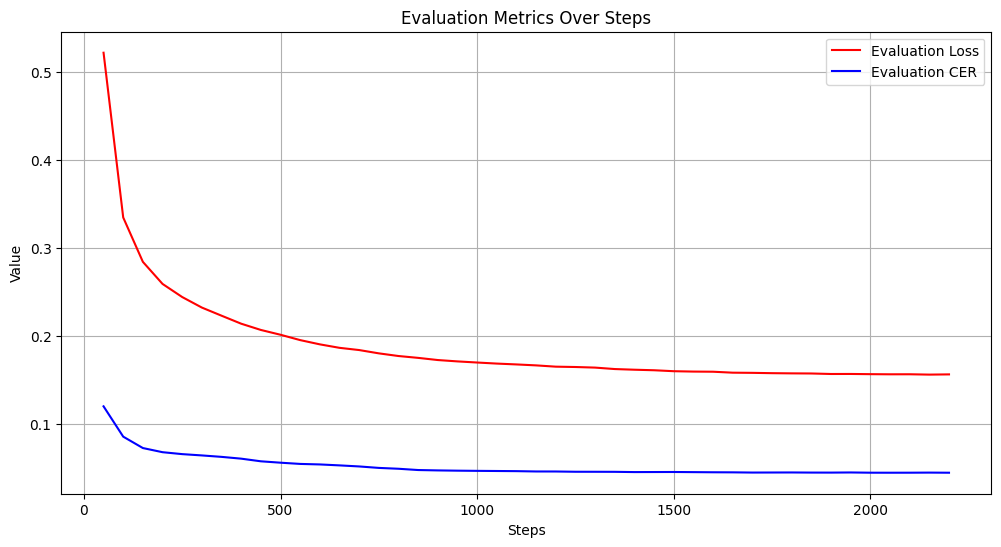

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df_eval['step'], df_eval['eval_loss'], label='Evaluation Loss', color='red')
plt.plot(df_eval['step'], df_eval['eval_cer'], label='Evaluation CER', color='blue')
plt.title('Evaluation Metrics Over Steps')
plt.xlabel('Steps')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

## Analysis of Training and Evaluation Metrics

Based on the plots generated, we can observe the following trends and insights:

### 1. Learning Rate Over Steps
The 'Learning Rate Over Steps' plot shows a **decreasing trend in the learning rate** as the training progresses. This is a common practice in deep learning, often referred to as a learning rate schedule, where the learning rate is gradually reduced to allow for finer adjustments to the model weights and to help the model converge more stably in later stages of training. The detailed view clearly illustrates this decay, indicating that the optimizer is taking smaller steps over time.

### 2. Training Metrics Over Steps (Loss and Gradient Norm)
*   **Training Loss**: The 'Training Loss Over Steps' plot shows a **decreasing trend in training loss**. This indicates that the model is successfully learning from the training data and improving its performance over time. A continuous decrease, especially in the early steps, is expected.
*   **Gradient Norm**: The 'Gradient Norm Over Steps' plot reveals the magnitude of the gradients. Generally, we expect the gradient norm to decrease as the model approaches convergence, as the updates to the weights become smaller. Significant fluctuations or spikes in the gradient norm could indicate instability in training or issues like exploding gradients, while a very low and flat gradient norm might suggest vanishing gradients or that the model is stuck in a local minimum. From the plot, we can observe that the gradient norm also tends to decrease alongside the loss, which is a healthy sign for training stability.

### 3. Evaluation Metrics Over Steps (Loss and CER)
*   **Evaluation Loss**: The 'Evaluation Loss Over Steps' plot, which tracks the model's performance on unseen data, also shows a **decreasing trend**. This is crucial as it demonstrates that the model is generalizing well and not just memorizing the training data. Ideally, the evaluation loss should decrease in parallel with the training loss, but it might plateau or even start increasing if the model begins to overfit.
*   **Evaluation CER (Character Error Rate)**: The 'Evaluation CER Over Steps' plot similarly exhibits a **decreasing trend**. CER is a direct measure of the model's accuracy in character recognition tasks. A decrease in CER indicates that the model is becoming more accurate in predicting character sequences on the evaluation dataset. The convergence of CER towards a lower value is the ultimate goal for such models.

### Overall Summary:
The plots collectively suggest a **healthy training process**. The learning rate is decaying, leading to a reduction in both training and evaluation losses, as well as the character error rate. The gradient norm also appears to be managed well, not showing extreme instability. These trends indicate that the model is learning effectively and generalizing well to new data. Further analysis would involve looking for signs of overfitting (e.g., evaluation loss increasing while training loss continues to decrease) or underfitting (e.g., both losses remaining high), and potentially optimizing hyperparameters based on these observations.